In [2]:
import matplotlib.pyplot as plt
import networkx as nx


def afficher_graphe(graphe, titre, layout=None, afficher_labels=True):
    """Affiche un graphe avec un style lisible et stable."""
    plt.figure(figsize=(7, 5))
    positions = layout(graphe) if layout else nx.spring_layout(graphe, seed=42)
    nx.draw_networkx(
        graphe,
        positions,
        with_labels=afficher_labels,
        node_color="#ffd166",
        edge_color="#26547c",
        node_size=900,
        font_size=10,
        arrows=graphe.is_directed(),
    )
    if nx.get_edge_attributes(graphe, "weight"):
        nx.draw_networkx_edge_labels(
            graphe,
            positions,
            edge_labels=nx.get_edge_attributes(graphe, "weight"),
        )
    plt.title(titre)
    plt.axis("off")
    plt.show()


# JOUR 5 : NetworkX — graphes et visualisations

Chaque bloc peut être exécuté séparément après le bloc d'importation.

## 5.1 Concepts théoriques

- Un nœud représente un sommet.
- Une arête représente un lien entre deux nœuds.
- `Graph` est non orienté, `DiGraph` est orienté.
- `MultiGraph` et `MultiDiGraph` autorisent plusieurs arêtes entre deux nœuds.
- Un graphe pondéré associe un attribut `weight` aux arêtes.

In [ ]:
# 5.2 Les quatre types de graphes
G = nx.Graph()
D = nx.DiGraph()
M = nx.MultiGraph()
MD = nx.MultiDiGraph()

print(f"Graph      : orienté={G.is_directed()}, multigraphe={G.is_multigraph()}")
print(f"DiGraph    : orienté={D.is_directed()}, multigraphe={D.is_multigraph()}")
print(f"MultiGraph : orienté={M.is_directed()}, multigraphe={M.is_multigraph()}")
print(f"MultiDiGraph: orienté={MD.is_directed()}, multigraphe={MD.is_multigraph()}")

Nœuds après ajout : [(1, {}), (2, {}), (3, {}), (4, {}), (5, {}), ('Alice', {'groupe': 'alpha'}), ('Bob', {'groupe': 'alpha'}), ((2, 3), {})]
Nœuds après suppression : [(1, {}), (2, {}), (3, {}), ('Alice', {'groupe': 'alpha'}), ('Bob', {'groupe': 'alpha'})]


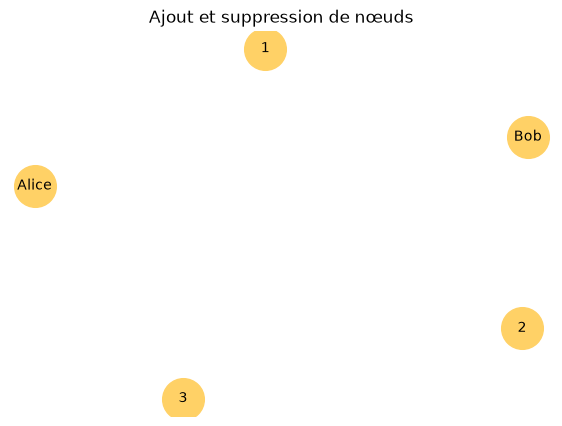

In [11]:
# 5.3 Ajouter et supprimer des nœuds
G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5])
G.add_nodes_from(["Alice", "Bob"], groupe="alpha")
G.add_node((2, 3))
print("Nœuds après ajout :", list(G.nodes(data=True)))

G.remove_node((2, 3))
G.remove_nodes_from([4, 5])
print("Nœuds après suppression :", list(G.nodes(data=True)))

afficher_graphe(G, "Ajout et suppression de nœuds")

Arêtes : [(1, 2, {}), (1, 4, {}), (1, 3, {'weight': 5, 'relation': 'diagonale'}), (2, 3, {}), (2, 4, {'weight': 2, 'relation': 'diagonale'}), (3, 4, {})]


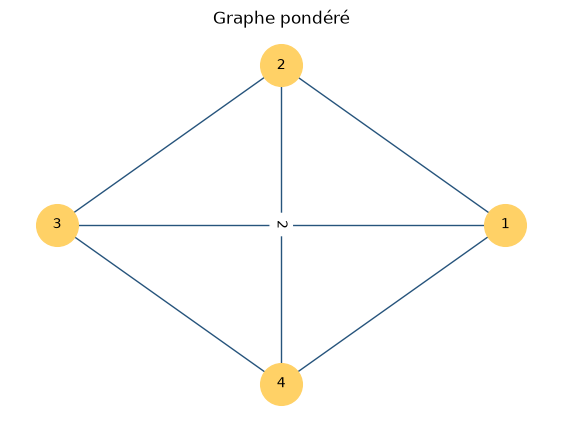

In [4]:
# 5.4 Ajouter des arêtes et visualiser un graphe pondéré
G = nx.Graph()
G.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 1)])
G.add_edge(1, 3, weight=5, relation="diagonale")
G.add_edge(2, 4, weight=2, relation="diagonale")

print("Arêtes :", list(G.edges(data=True)))
afficher_graphe(G, "Graphe pondéré", layout=nx.circular_layout)

Attributs du nœud 1 : {'nom': 'Alice', 'statut': 'actif'}
Attributs de l'arête (1, 2) : {'weight': 5}


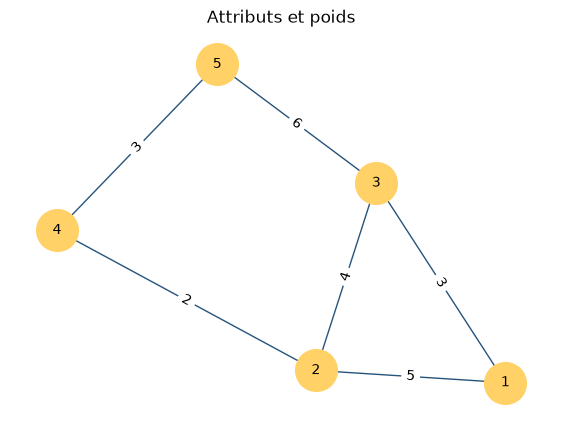

In [18]:
# 5.5 Attributs des nœuds et des arêtes
G = nx.Graph()
G.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 5), (4, 5)])

noms = {1: "Alice", 2: "Bob", 3: "Charlie", 4: "David", 5: "Eve"}
for noeud, nom in noms.items():
    G.nodes[noeud]["nom"] = nom
    G.nodes[noeud]["statut"] = "actif"

poids = {(1, 2): 5, (1, 3): 3, (2, 3): 4, (2, 4): 2, (3, 5): 6, (4, 5): 3}
nx.set_edge_attributes(G, poids, "weight")

print("Attributs du nœud 1 :", G.nodes[1])
print("Attributs de l'arête (1, 2) :", G[1][2])
afficher_graphe(G, "Attributs et poids", layout=nx.spring_layout)

In [19]:
# 5.6 Inspecter un graphe
print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre d'arêtes :", G.number_of_edges())
print("Degrés :", dict(G.degree()))
print("Voisins du nœud 1 :", list(G.neighbors(1)))
print("Arête (1, 2) présente :", G.has_edge(1, 2))
print("Graphe orienté :", G.is_directed())
print("Somme des poids :", G.size(weight="weight"))

Nombre de nœuds : 5
Nombre d'arêtes : 6
Degrés : {1: 2, 2: 3, 3: 3, 4: 2, 5: 2}
Voisins du nœud 1 : [2, 3]
Arête (1, 2) présente : True
Graphe orienté : False
Somme des poids : 23.0


## 5.7 Graphes classiques

Chaque cellule suivante crée un graphe et affiche immédiatement son visuel.

K5 : 5 nœuds, 10 arêtes


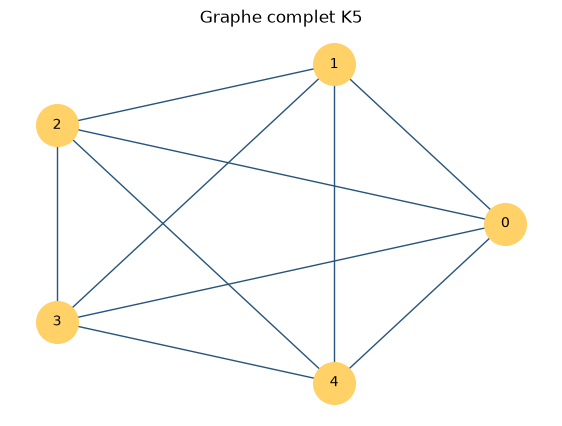

In [5]:
# Graphe complet K5
K5 = nx.complete_graph(5)
print(f"K5 : {K5.number_of_nodes()} nœuds, {K5.number_of_edges()} arêtes")
afficher_graphe(K5, "Graphe complet K5", layout=nx.circular_layout)

P10 : 10 nœuds, 9 arêtes


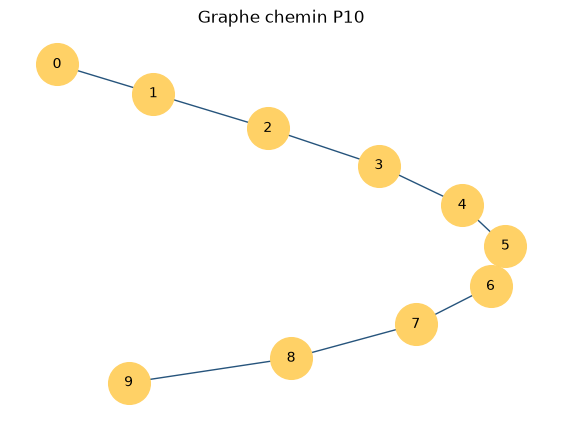

In [22]:
# Graphe chemin P10
P10 = nx.path_graph(10)
print(f"P10 : {P10.number_of_nodes()} nœuds, {P10.number_of_edges()} arêtes")
afficher_graphe(P10, "Graphe chemin P10", layout=nx.spring_layout)

C6 : 6 nœuds, 6 arêtes


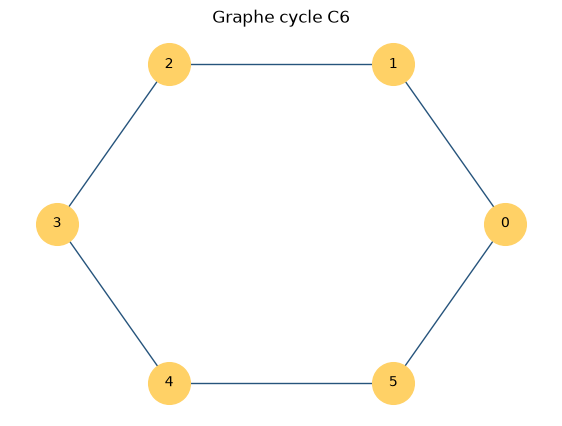

In [23]:
# Graphe cycle C6
C6 = nx.cycle_graph(6)
print(f"C6 : {C6.number_of_nodes()} nœuds, {C6.number_of_edges()} arêtes")
afficher_graphe(C6, "Graphe cycle C6", layout=nx.circular_layout)

S5 : 6 nœuds, 5 arêtes


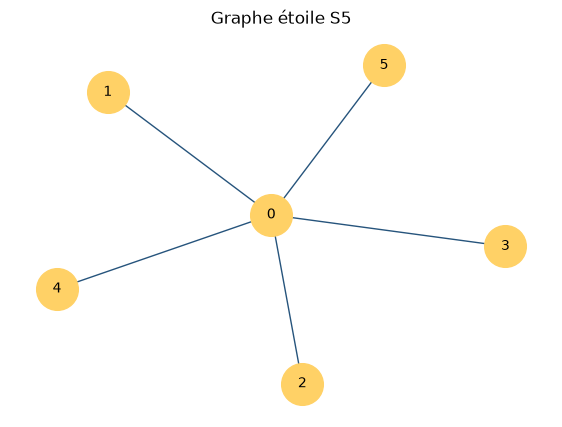

In [9]:
# Graphe étoile S5
S5 = nx.star_graph(5)
print(f"S5 : {S5.number_of_nodes()} nœuds, {S5.number_of_edges()} arêtes")
afficher_graphe(S5, "Graphe étoile S5", layout=nx.spring_layout)

W6 : 6 nœuds, 10 arêtes


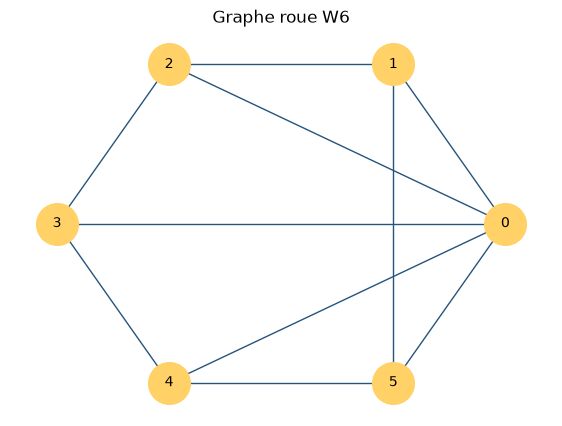

In [26]:
# Graphe roue W6
W6 = nx.wheel_graph(6)
print(f"W6 : {W6.number_of_nodes()} nœuds, {W6.number_of_edges()} arêtes")
afficher_graphe(W6, "Graphe roue W6", layout=nx.circular_layout)

G2D : 12 nœuds, 17 arêtes


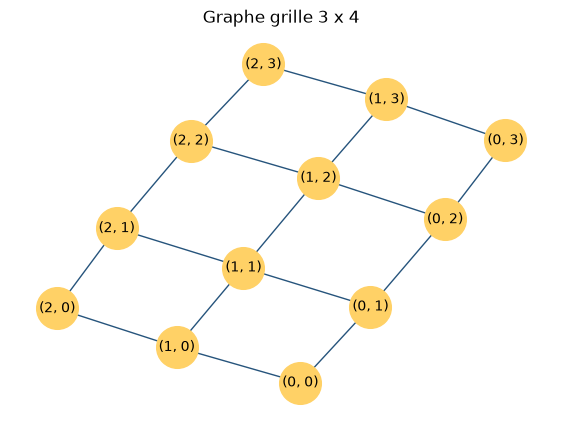

In [27]:
# Graphe grille 3 x 4
G2D = nx.grid_2d_graph(3, 4)
print(f"G2D : {G2D.number_of_nodes()} nœuds, {G2D.number_of_edges()} arêtes")
afficher_graphe(G2D, "Graphe grille 3 x 4", layout=nx.spring_layout)

G2D : 12 nœuds, 17 arêtes


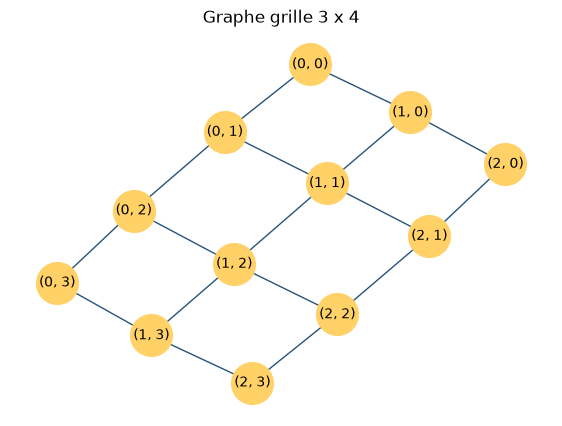

In [29]:
# Graphe grille 3 x 4
G2D = nx.grid_2d_graph(3, 4)
print(f"G2D : {G2D.number_of_nodes()} nœuds, {G2D.number_of_edges()} arêtes")
afficher_graphe(G2D, "Graphe grille 3 x 4")

## 5.8 Graphes aléatoires

La graine `42` rend les exemples reproductibles.

ER : 20 nœuds, 37 arêtes


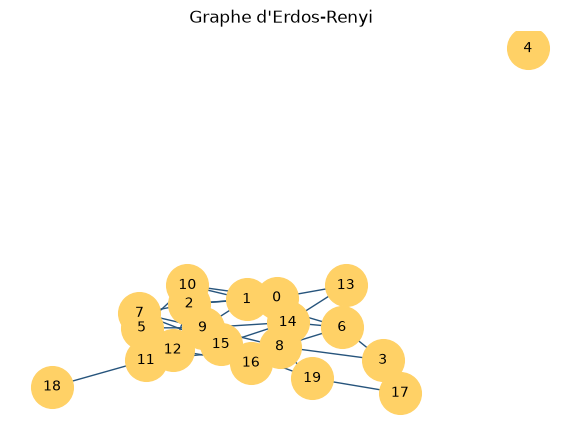

In [30]:
# Graphe d'Erdos-Renyi
ER = nx.erdos_renyi_graph(n=20, p=0.2, seed=42)
print(f"ER : {ER.number_of_nodes()} nœuds, {ER.number_of_edges()} arêtes")
afficher_graphe(ER, "Graphe d'Erdos-Renyi", layout=nx.spring_layout)

BA : 20 nœuds, 36 arêtes


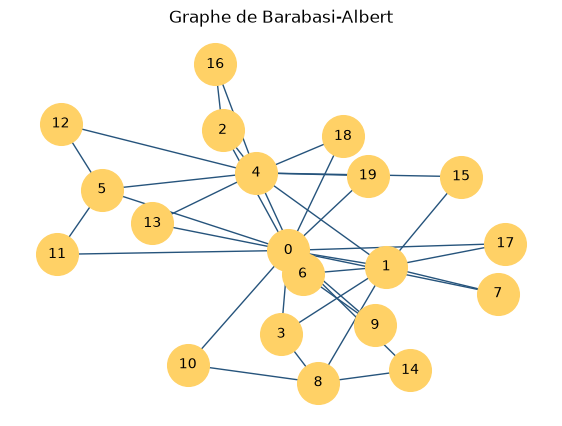

In [14]:
# Graphe de Barabasi-Albert
BA = nx.barabasi_albert_graph(n=20, m=2, seed=42)
print(f"BA : {BA.number_of_nodes()} nœuds, {BA.number_of_edges()} arêtes")
afficher_graphe(BA, "Graphe de Barabasi-Albert", layout=nx.spring_layout)

WS : 20 nœuds, 40 arêtes


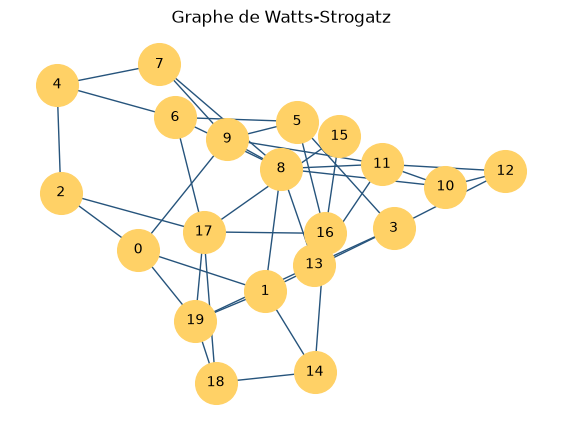

In [15]:
# Graphe de Watts-Strogatz
WS = nx.watts_strogatz_graph(n=20, k=4, p=0.3, seed=42)
print(f"WS : {WS.number_of_nodes()} nœuds, {WS.number_of_edges()} arêtes")
afficher_graphe(WS, "Graphe de Watts-Strogatz", layout=nx.spring_layout)

RR : 20 nœuds, 30 arêtes
Degrés présents : [3]


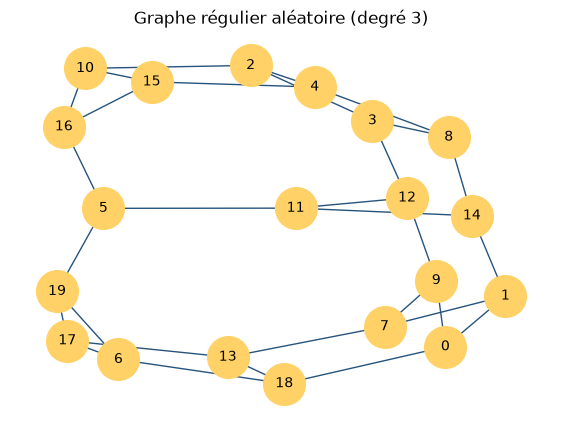

In [16]:
# Graphe regulier aleatoire
RR = nx.random_regular_graph(d=3, n=20, seed=42)
print(f"RR : {RR.number_of_nodes()} nœuds, {RR.number_of_edges()} arêtes")
print("Degrés présents :", sorted(set(dict(RR.degree()).values())))
afficher_graphe(RR, "Graphe régulier aléatoire (degré 3)", layout=nx.spring_layout)